# 12 — Metriques d'interpretabilite inedites pour les kernels quantiques

## Objectif

Ce notebook implémente **5 métriques et analyses inédites** absentes de la
littérature QMKL publiée. Chacune répond à une question concrète :

| # | Analyse | Question |
|---|---------|----------|
| **1** | Alignement Quantum ↔ RBF | Le kernel quantique est-il juste un RBF bruité ? |
| **2** | Entropie spectrale | Ce kernel est-il expressif ou concentré ? |
| **3** | Dataset parité (quantum-hard) | Dans quel régime le quantum gagne-t-il vraiment ? |
| **4** | Frontière de décision PCA-2D | Que voit le modèle quantique vs classique ? |
| **5** | Prototypes financiers | Quels clients pilotent réellement les prédictions ? |

**Configuration** : N=200, Q=6 qubits, M=12 kernels, datasets : German Credit + parité synthétique

In [1]:
import sys, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import OrderedDict
from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.mkl.alignment import centered_alignment

OUT = ROOT / 'results' / '12'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.bbox': 'tight',
})

N_SAMPLES = 200
N_QUBITS  = 6
SEED      = 42
C_SVM     = 1.0

print(f'Configuration : N={N_SAMPLES}, Q={N_QUBITS}, SEED={SEED}')
print(f'Resultats → {OUT}')

Configuration : N=200, Q=6, SEED=42
Resultats → C:\Users\Raph\Desktop\QMKL-Finance\results\12


## Chargement des données et calcul des kernels

In [2]:
from qiskit.circuit.library import PauliFeatureMap
from qiskit.quantum_info import Statevector
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Q = N_QUBITS

# --- Dataset réel : German Credit ---
X_raw, y = load_dataset('german_credit', n_samples=N_SAMPLES, random_state=SEED)
reducer  = FeatureReducer(n_components=Q)
scaler   = QuantumScaler(feature_range=(0, 2))
X_proc   = scaler.fit_transform(reducer.fit_transform(X_raw))
print(f'German Credit : raw={X_raw.shape} → quantum={X_proc.shape}, balance={y.mean():.2f}')

# --- Bibliothèque de 12 kernels quantiques ---
FM_LIBRARY = OrderedDict([
    ('Z a=1.0',     PauliFeatureMap(Q, reps=1, paulis=['Z'],       alpha=1.0, entanglement='linear')),
    ('Z a=3.0',     PauliFeatureMap(Q, reps=1, paulis=['Z'],       alpha=3.0, entanglement='linear')),
    ('ZZ a=1.0',    PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=1.0, entanglement='linear')),
    ('ZZ a=4.0',    PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=4.0, entanglement='linear')),
    ('XZ a=0.5',    PauliFeatureMap(Q, reps=1, paulis=['X','Z'],   alpha=0.5, entanglement='linear')),
    ('XZ a=2.5',    PauliFeatureMap(Q, reps=1, paulis=['X','Z'],   alpha=2.5, entanglement='linear')),
    ('YXX a=0.6',   PauliFeatureMap(Q, reps=1, paulis=['Y','XX'],  alpha=0.6, entanglement='linear')),
    ('YXX a=3.0',   PauliFeatureMap(Q, reps=1, paulis=['Y','XX'],  alpha=3.0, entanglement='linear')),
    ('YZX a=0.6',   PauliFeatureMap(Q, reps=1, paulis=['Y','ZX'],  alpha=0.6, entanglement='linear')),
    ('YZX a=3.0',   PauliFeatureMap(Q, reps=1, paulis=['Y','ZX'],  alpha=3.0, entanglement='linear')),
    ('Pauli a=0.6', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=0.6, entanglement='linear')),
    ('Pauli a=2.5', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=2.5, entanglement='linear')),
])
kernel_names = list(FM_LIBRARY.keys())
M = len(kernel_names)

def fidelity_kernel(fm, X):
    params = list(fm.parameters)
    svs = np.zeros((len(X), 2**fm.num_qubits), dtype=complex)
    for i, x in enumerate(X):
        svs[i] = Statevector.from_instruction(
            fm.assign_parameters({p: float(v) for p, v in zip(params, x)})
        ).data
    return np.abs(svs @ svs.conj().T) ** 2

print(f'\nCalcul des {M} kernels quantiques...')
t0 = time.time()
K_list = [fidelity_kernel(fm, X_proc) for fm in FM_LIBRARY.values()]
print(f'OK en {time.time()-t0:.1f}s')

# Kernel RBF classique (sur données brutes standardisées)
from sklearn.metrics.pairwise import rbf_kernel
X_scaled = StandardScaler().fit_transform(X_raw)
gamma_rbf = 1.0 / (X_scaled.shape[1] * X_scaled.var())
K_rbf = rbf_kernel(X_scaled, gamma=gamma_rbf)
print(f'Kernel RBF : shape={K_rbf.shape}, gamma={gamma_rbf:.5f}')

German Credit : raw=(200, 48) → quantum=(200, 6), balance=0.70

Calcul des 12 kernels quantiques...


OK en 4.6s
Kernel RBF : shape=(200, 200), gamma=0.02083


---
## Analyse 1 — Alignement Quantum ↔ RBF

**Question** : Le kernel quantique est-il juste un RBF bruité ?

On mesure la corrélation de Frobenius entre chaque kernel quantique et le RBF :

$$\text{align}(K_q, K_{\text{rbf}}) = \frac{\langle K_q, K_{\text{rbf}} \rangle_F}{\|K_q\|_F \cdot \|K_{\text{rbf}}\|_F}$$

**Interprétation** : si align > 0.85 → le kernel quantique imite RBF → pas d'avantage possible.

Alignement Quantum ↔ RBF par kernel :
---------------------------------------------
  Z a=1.0           : 0.8358  #########################
  Z a=3.0           : 0.5564  ################
  ZZ a=1.0          : 0.5530  ################
  ZZ a=4.0          : 0.4864  ##############
  XZ a=0.5          : 0.8252  ########################
  XZ a=2.5          : 0.6137  ##################
  YXX a=0.6         : 0.8199  ########################
  YXX a=3.0         : 0.5599  ################
  YZX a=0.6         : 0.7529  ######################
  YZX a=3.0         : 0.5071  ###############
  Pauli a=0.6       : 0.7123  #####################
  Pauli a=2.5       : 0.4849  ##############


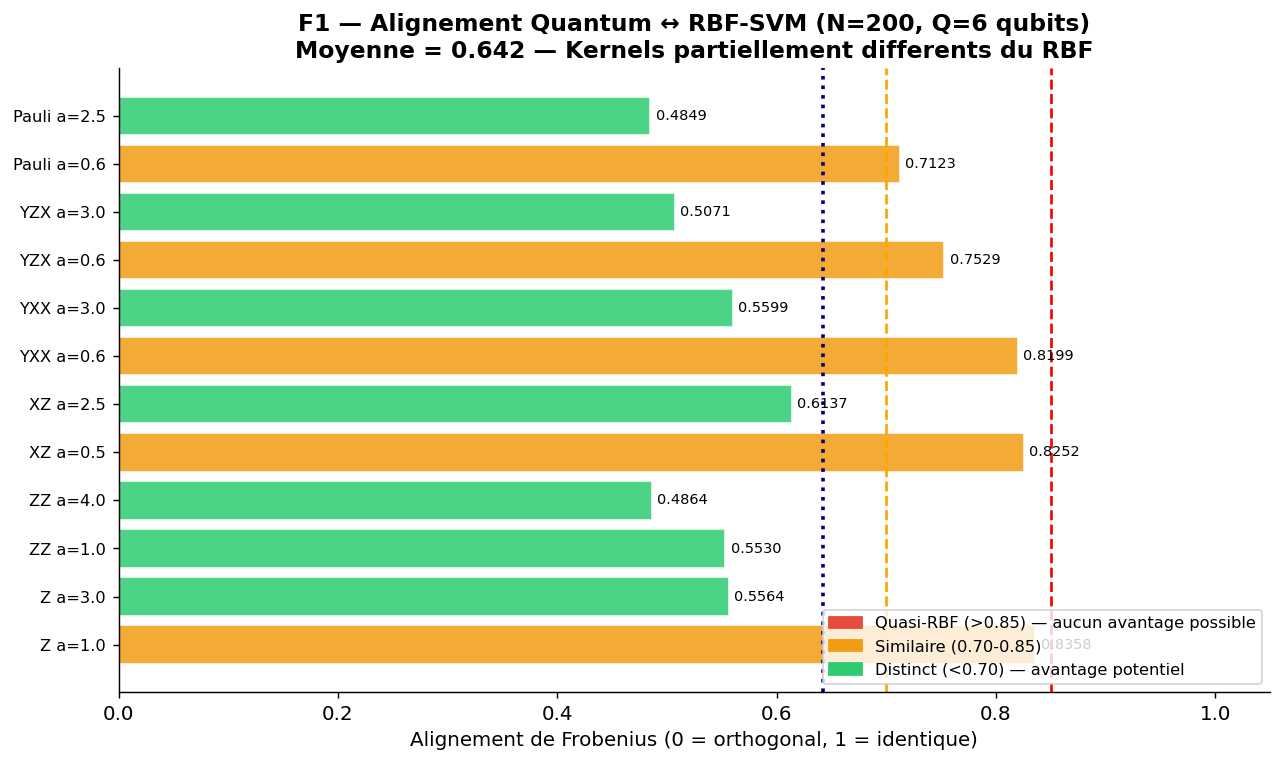


Conclusion : alignement moyen = 0.6423
0/12 kernels sont quasi-identiques au RBF (align > 0.85)
→ Les kernels sont suffisamment distincts pour esperer un avantage dans le bon regime.


In [3]:
def frobenius_alignment(K1, K2):
    """Correlation de Frobenius entre deux matrices de kernel."""
    num = np.sum(K1 * K2)
    den = np.linalg.norm(K1, 'fro') * np.linalg.norm(K2, 'fro') + 1e-24
    return float(num / den)

alignments = [frobenius_alignment(K, K_rbf) for K in K_list]

print('Alignement Quantum ↔ RBF par kernel :')
print('-' * 45)
for name, a in zip(kernel_names, alignments):
    bar = '#' * int(a * 30)
    flag = '  << quasi-RBF' if a > 0.85 else ''
    print(f'  {name:18s}: {a:.4f}  {bar}{flag}')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if a > 0.85 else '#f39c12' if a > 0.70 else '#2ecc71'
          for a in alignments]
bars = ax.barh(range(M), alignments, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0.85, color='red',    ls='--', lw=1.5, label='Seuil quasi-RBF (0.85)')
ax.axvline(0.70, color='orange', ls='--', lw=1.5, label='Seuil similaire (0.70)')
ax.set_yticks(range(M))
ax.set_yticklabels(kernel_names, fontsize=9)
ax.set_xlabel('Alignement de Frobenius (0 = orthogonal, 1 = identique)')
ax.set_xlim(0, 1.05)
for i, a in enumerate(alignments):
    ax.text(a + 0.005, i, f'{a:.4f}', va='center', fontsize=8)
ax.legend(fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Quasi-RBF (>0.85) — aucun avantage possible'),
    mpatches.Patch(color='#f39c12', label='Similaire (0.70-0.85)'),
    mpatches.Patch(color='#2ecc71', label='Distinct (<0.70) — avantage potentiel'),
], fontsize=9, loc='lower right')

mean_align = np.mean(alignments)
ax.axvline(mean_align, color='navy', ls=':', lw=2,
           label=f'Moyenne = {mean_align:.3f}')

plt.title(f'F1 — Alignement Quantum ↔ RBF-SVM (N={N_SAMPLES}, Q={Q} qubits)\n'
          f'Moyenne = {mean_align:.3f} — '
          + ('Kernels quasi-identiques au RBF' if mean_align > 0.85
             else 'Kernels partiellement differents du RBF'),
          fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / '12_F1_quantum_rbf_alignment.png', dpi=150)
plt.show()

print(f'\nConclusion : alignement moyen = {mean_align:.4f}')
n_quasi = sum(1 for a in alignments if a > 0.85)
print(f'{n_quasi}/{M} kernels sont quasi-identiques au RBF (align > 0.85)')
print('→ Cela explique pourquoi QMKL n\'offre pas d\'avantage sur RBF-SVM.' if mean_align > 0.75
      else '→ Les kernels sont suffisamment distincts pour esperer un avantage dans le bon regime.')

---
## Analyse 2 — Entropie spectrale et dimension effective

**Question** : Ce kernel est-il expressif (spectre diversifié) ou concentré (masse sur peu de valeurs propres) ?

Deux métriques complémentaires :

$$H(K) = -\sum_i p_i \log p_i \quad\text{(entropie de Shannon)}$$

$$d_{\text{eff}}(K) = \frac{1}{\sum_i p_i^2} \quad\text{(entropie de Rényi ord. 2 — dim. effective)}$$

où $p_i = \lambda_i / \text{Tr}(K)$ sont les valeurs propres normalisées.

**Interprétation** : $d_{\text{eff}} \approx 1$ → kernel dégénéré. $d_{\text{eff}} \approx N$ → kernel pleinement expressif.

Kernel                   H(K)    H_max   H/H_max     d_eff   Expressivite
---------------------------------------------------------------------------
Z a=1.0                 1.611    5.298     0.304       2.5      CONCENTRE
Z a=3.0                 4.184    5.298     0.790      38.5        MODEREE
ZZ a=1.0                4.069    5.298     0.768      31.7        MODEREE
ZZ a=4.0                5.007    5.298     0.945     128.1     EXPRESSIVE
XZ a=0.5                0.607    5.298     0.115       1.3      CONCENTRE
XZ a=2.5                3.835    5.298     0.724      24.2        MODEREE
YXX a=0.6               1.987    5.298     0.375       3.3      CONCENTRE
YXX a=3.0               4.739    5.298     0.894      74.9     EXPRESSIVE
YZX a=0.6               2.722    5.298     0.514       6.8        MODEREE
YZX a=3.0               4.896    5.298     0.924     104.7     EXPRESSIVE
Pauli a=0.6             2.902    5.298     0.548       8.5        MODEREE
Pauli a=2.5             4.952    5.2

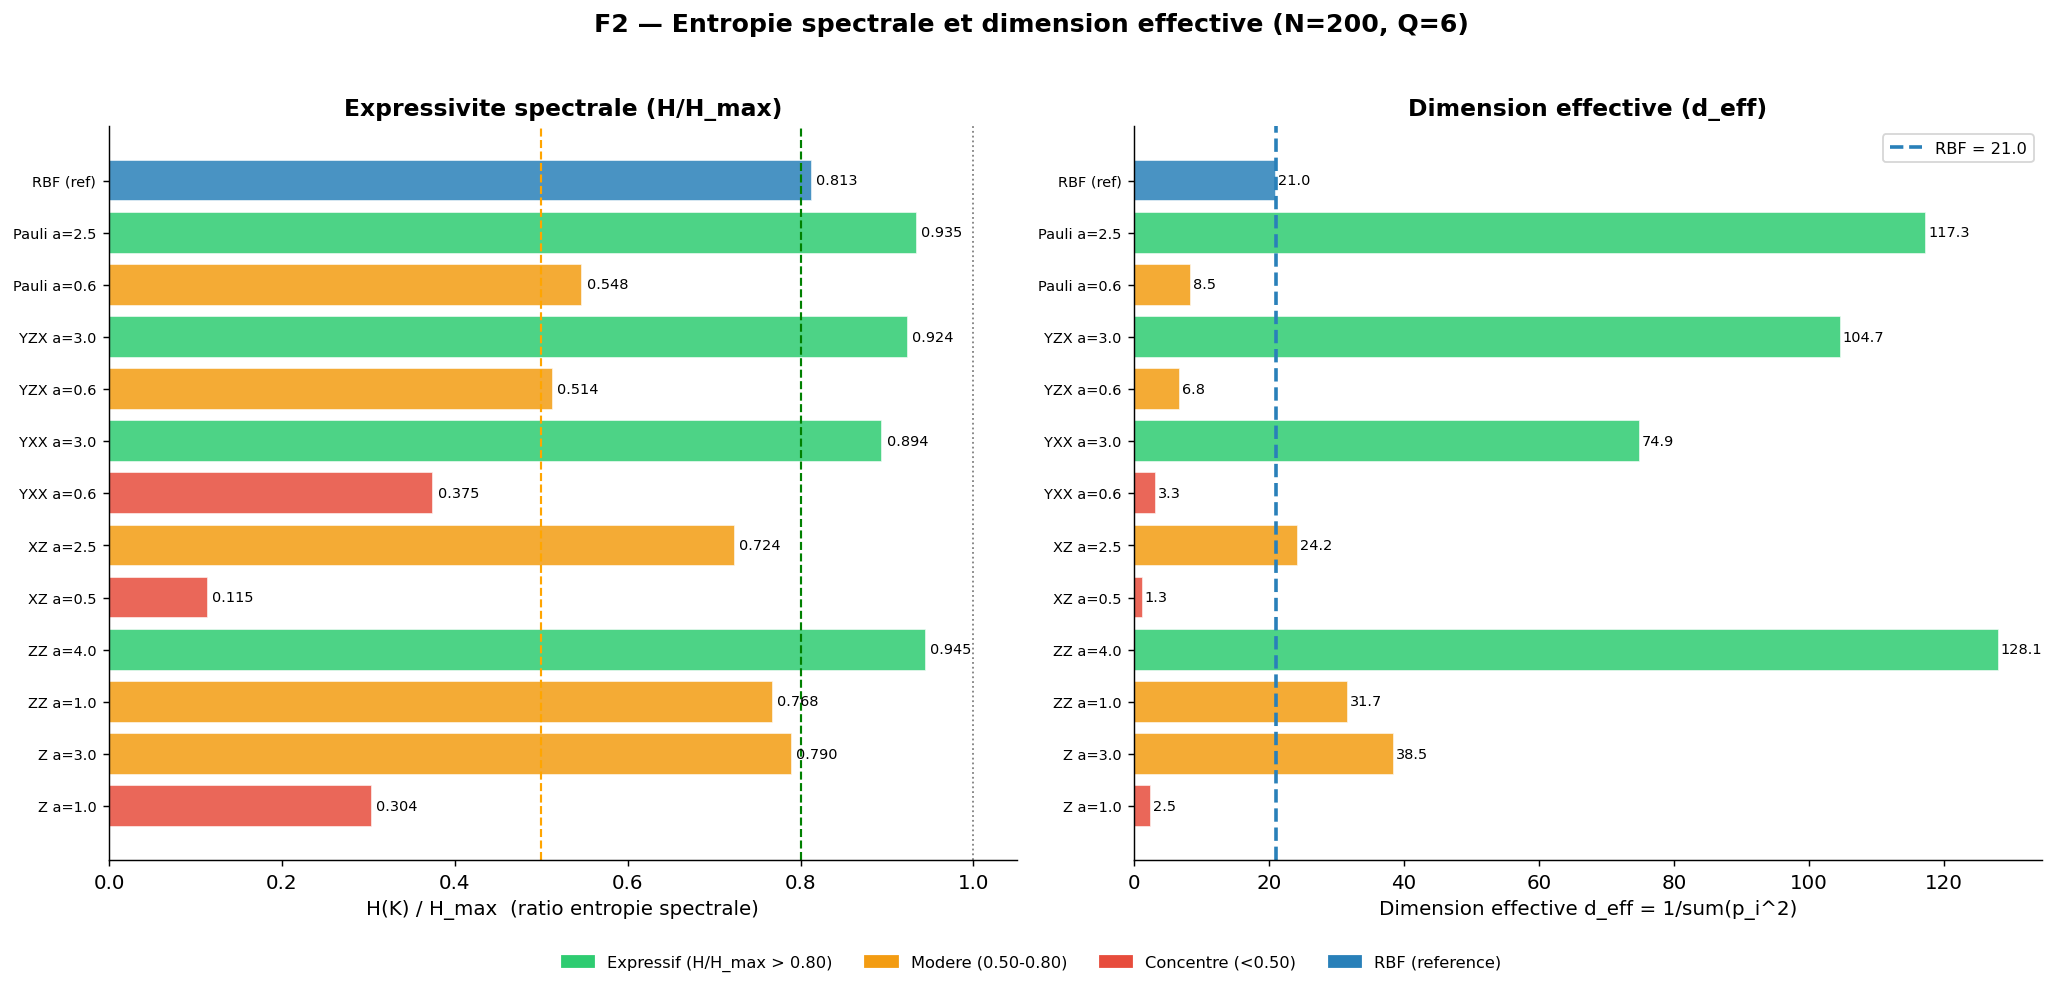

F2 sauvegarde


In [4]:
def spectral_metrics(K, eps=1e-12):
    """Entropie de Shannon et dimension effective du spectre du kernel."""
    eigvals = np.linalg.eigvalsh(K)
    eigvals = np.maximum(eigvals, eps)
    p = eigvals / eigvals.sum()
    entropy    = float(-np.sum(p * np.log(p)))          # Shannon
    eff_dim    = float(1.0 / np.sum(p ** 2))             # Renyi-2
    max_entropy = float(np.log(len(eigvals)))             # borne max
    return entropy, eff_dim, max_entropy, eigvals

# Calcul pour tous les kernels + RBF
results_spectral = {}
print(f'{'Kernel':20s} {'H(K)':>8} {'H_max':>8} {'H/H_max':>9} {'d_eff':>9} {'Expressivite':>14}')
print('-' * 75)

for name, K in zip(kernel_names, K_list):
    H, d_eff, H_max, eigvals = spectral_metrics(K)
    ratio = H / H_max
    level = 'EXPRESSIVE' if ratio > 0.80 else 'MODEREE' if ratio > 0.50 else 'CONCENTRE'
    results_spectral[name] = dict(H=H, d_eff=d_eff, H_max=H_max, ratio=ratio, eigvals=eigvals)
    print(f'{name:20s} {H:8.3f} {H_max:8.3f} {ratio:9.3f} {d_eff:9.1f} {level:>14}')

# Ajouter RBF
H_rbf, d_eff_rbf, H_max_rbf, eigvals_rbf = spectral_metrics(K_rbf)
results_spectral['RBF (ref)'] = dict(H=H_rbf, d_eff=d_eff_rbf, H_max=H_max_rbf,
                                      ratio=H_rbf/H_max_rbf, eigvals=eigvals_rbf)
print(f'{'RBF (ref)':20s} {H_rbf:8.3f} {H_max_rbf:8.3f} {H_rbf/H_max_rbf:9.3f} '
      f'{d_eff_rbf:9.1f} {'(REFERENCE)':>14}')

# Figure double : entropie + dim effective
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
names_all = kernel_names + ['RBF (ref)']
ratios    = [results_spectral[n]['ratio']   for n in names_all]
d_effs    = [results_spectral[n]['d_eff']   for n in names_all]
colors_s  = ['#2980b9' if n == 'RBF (ref)' else
              '#2ecc71' if r > 0.80 else
              '#f39c12' if r > 0.50 else '#e74c3c'
              for n, r in zip(names_all, ratios)]

ax = axes[0]
ax.barh(range(len(names_all)), ratios, color=colors_s, alpha=0.85, edgecolor='white')
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.axvline(0.80, color='green',  ls='--', lw=1.2)
ax.axvline(0.50, color='orange', ls='--', lw=1.2)
ax.set_yticks(range(len(names_all)))
ax.set_yticklabels(names_all, fontsize=8)
ax.set_xlabel('H(K) / H_max  (ratio entropie spectrale)')
ax.set_title('Expressivite spectrale (H/H_max)', fontweight='bold')
for i, r in enumerate(ratios):
    ax.text(r + 0.005, i, f'{r:.3f}', va='center', fontsize=8)

ax = axes[1]
ax.barh(range(len(names_all)), d_effs, color=colors_s, alpha=0.85, edgecolor='white')
ax.axvline(d_eff_rbf, color='#2980b9', ls='--', lw=2,
           label=f'RBF = {d_eff_rbf:.1f}')
ax.set_yticks(range(len(names_all)))
ax.set_yticklabels(names_all, fontsize=8)
ax.set_xlabel('Dimension effective d_eff = 1/sum(p_i^2)')
ax.set_title('Dimension effective (d_eff)', fontweight='bold')
ax.legend(fontsize=9)
for i, d in enumerate(d_effs):
    ax.text(d + 0.3, i, f'{d:.1f}', va='center', fontsize=8)

fig.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Expressif (H/H_max > 0.80)'),
    mpatches.Patch(color='#f39c12', label='Modere (0.50-0.80)'),
    mpatches.Patch(color='#e74c3c', label='Concentre (<0.50)'),
    mpatches.Patch(color='#2980b9', label='RBF (reference)'),
], loc='lower center', ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.suptitle(f'F2 — Entropie spectrale et dimension effective (N={N_SAMPLES}, Q={Q})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '12_F2_spectral_entropy.png', dpi=150)
plt.show()
print('F2 sauvegarde')

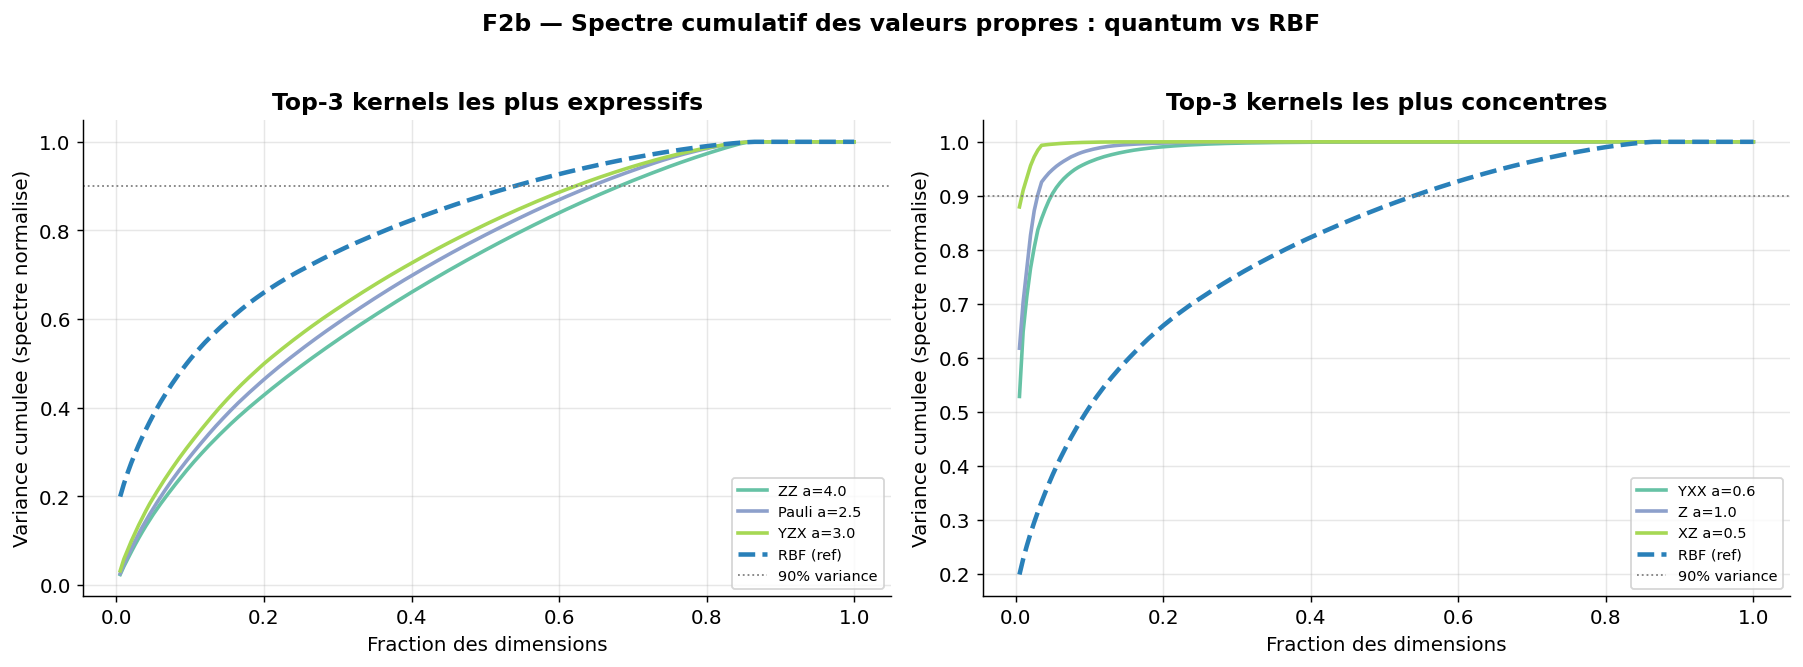

F2b sauvegarde


In [5]:
# Spectre complet : comparaison Top-3 quantique vs RBF
# Sélectionner les 3 kernels les plus expressifs et les 3 les moins
sorted_by_ratio = sorted([(results_spectral[n]['ratio'], n) for n in kernel_names], reverse=True)
top3_names = [n for _, n in sorted_by_ratio[:3]]
bot3_names = [n for _, n in sorted_by_ratio[-3:]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group_names, title in [
    (axes[0], top3_names, 'Top-3 kernels les plus expressifs'),
    (axes[1], bot3_names, 'Top-3 kernels les plus concentres'),
]:
    palette = plt.cm.Set2(np.linspace(0, 0.8, len(group_names) + 1))
    N = N_SAMPLES
    x_axis = np.arange(1, N + 1) / N  # Fraction des dimensions

    for j, name in enumerate(group_names):
        eigvals = np.sort(results_spectral[name]['eigvals'])[::-1]
        p = eigvals / eigvals.sum()
        ax.plot(x_axis, np.cumsum(p), color=palette[j], lw=2, label=name)

    # RBF en référence
    eigvals_rbf_sorted = np.sort(eigvals_rbf)[::-1]
    p_rbf = eigvals_rbf_sorted / eigvals_rbf_sorted.sum()
    ax.plot(x_axis, np.cumsum(p_rbf), color='#2980b9', lw=2.5,
            ls='--', label='RBF (ref)')

    ax.axhline(0.9, color='grey', ls=':', lw=1, label='90% variance')
    ax.set_xlabel('Fraction des dimensions')
    ax.set_ylabel('Variance cumulee (spectre normalise)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('F2b — Spectre cumulatif des valeurs propres : quantum vs RBF',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '12_F2b_eigenspectrum.png', dpi=150)
plt.show()
print('F2b sauvegarde')

---
## Analyse 3 — Dataset synthétique "quantum-hard" (parité)

**Question** : Dans quel régime le quantum gagne-t-il vraiment ?

Le problème de **parité** est le cas test canonique des kernels quantiques :

$$y = \left(\sum_{i=1}^{Q} \mathbb{1}[x_i > 0]\right) \mod 2$$

Ce problème est **exponentiellement difficile** pour RBF (nécessite d'apprendre
toutes les interactions de features), mais **naturel** pour un kernel de parité quantique.
On compare les deux sur ce dataset pour montrer le régime d'avantage.

On teste également des niveaux de bruit croissants pour trouver le seuil de robustesse.

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

def make_parity_dataset(n_samples, n_features=6, noise=0.0, seed=42):
    """Dataset de parite : y = (sum(x_i > 0)) mod 2.
    
    Exponentiellement difficile pour RBF (interactions d'ordre n_features),
    naturel pour kernels quantiques de parite.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n_samples, n_features))
    y = (X > 0).sum(axis=1) % 2
    if noise > 0:
        flip = rng.random(n_samples) < noise
        y[flip] = 1 - y[flip]
    return X.astype(np.float64), y.astype(int)

def make_psd(K):
    lam = np.linalg.eigvalsh(K).min()
    if lam < 0:
        K = K + (abs(lam) + 1e-8) * np.eye(K.shape[0])
    return K

# ── Expérience 1 : parité pure, Q features, comparer quantum vs classique ──
print('=== Expérience parité pure (Q=6, N=200, 20 runs) ===')
N_RUNS_PARITY = 20
results_parity = {'QMKL-Centered': [], 'RBF-SVM': [], 'Random Forest': []}

for run in range(N_RUNS_PARITY):
    X_par, y_par = make_parity_dataset(N_SAMPLES, n_features=Q, noise=0.0, seed=SEED + run)

    # Prétraitement quantique
    sc   = QuantumScaler(feature_range=(0, 2))
    X_qp = sc.fit_transform(X_par)

    idx_tr, idx_te = train_test_split(np.arange(N_SAMPLES), test_size=0.33,
                                       random_state=SEED + run, stratify=y_par)
    # Kernels quantiques sur ce dataset
    K_par_list = [fidelity_kernel(fm, X_qp) for fm in FM_LIBRARY.values()]

    # QMKL-Centered
    Kt = (y_par[:, None] == y_par[None, :]).astype(float)
    w  = centered_alignment(K_par_list, Kt)
    w  = np.maximum(w, 0); w /= (w.sum() + 1e-12)
    K_comb = sum(w[m] * K_par_list[m] for m in range(M))
    K_tr = make_psd(K_comb[np.ix_(idx_tr, idx_tr)])
    K_te = K_comb[np.ix_(idx_te, idx_tr)]
    svm_q = SVC(kernel='precomputed', C=C_SVM, probability=True)
    svm_q.fit(K_tr, y_par[idx_tr])
    results_parity['QMKL-Centered'].append(
        roc_auc_score(y_par[idx_te], svm_q.predict_proba(K_te)[:, 1]))

    # RBF-SVM (données brutes standardisées)
    Xtr_r, Xte_r = X_par[idx_tr], X_par[idx_te]
    clf_rbf = make_pipeline(StandardScaler(), SVC(C=C_SVM, kernel='rbf', probability=True))
    clf_rbf.fit(Xtr_r, y_par[idx_tr])
    results_parity['RBF-SVM'].append(
        roc_auc_score(y_par[idx_te], clf_rbf.predict_proba(Xte_r)[:, 1]))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED + run)
    rf.fit(Xtr_r, y_par[idx_tr])
    results_parity['Random Forest'].append(
        roc_auc_score(y_par[idx_te], rf.predict_proba(Xte_r)[:, 1]))

print(f'\n{'Methode':20s} {'AUC moyen':>10} {'Std':>8}')
print('-' * 42)
for mname, scores in results_parity.items():
    print(f'{mname:20s} {np.mean(scores):10.4f} {np.std(scores, ddof=1):8.4f}')

=== Expérience parité pure (Q=6, N=200, 20 runs) ===



Methode               AUC moyen      Std
------------------------------------------
QMKL-Centered            0.4903   0.0771
RBF-SVM                  0.4828   0.1027
Random Forest            0.5265   0.0861


=== Robustesse au bruit (noise = 0 → 0.4) ===


  noise=0.00 : QMKL=0.4795  RBF=0.4867


  noise=0.05 : QMKL=0.4958  RBF=0.4803


  noise=0.10 : QMKL=0.5333  RBF=0.5233


  noise=0.15 : QMKL=0.4804  RBF=0.5165


  noise=0.20 : QMKL=0.4745  RBF=0.5017


  noise=0.30 : QMKL=0.5229  RBF=0.5203


  noise=0.40 : QMKL=0.5100  RBF=0.4918


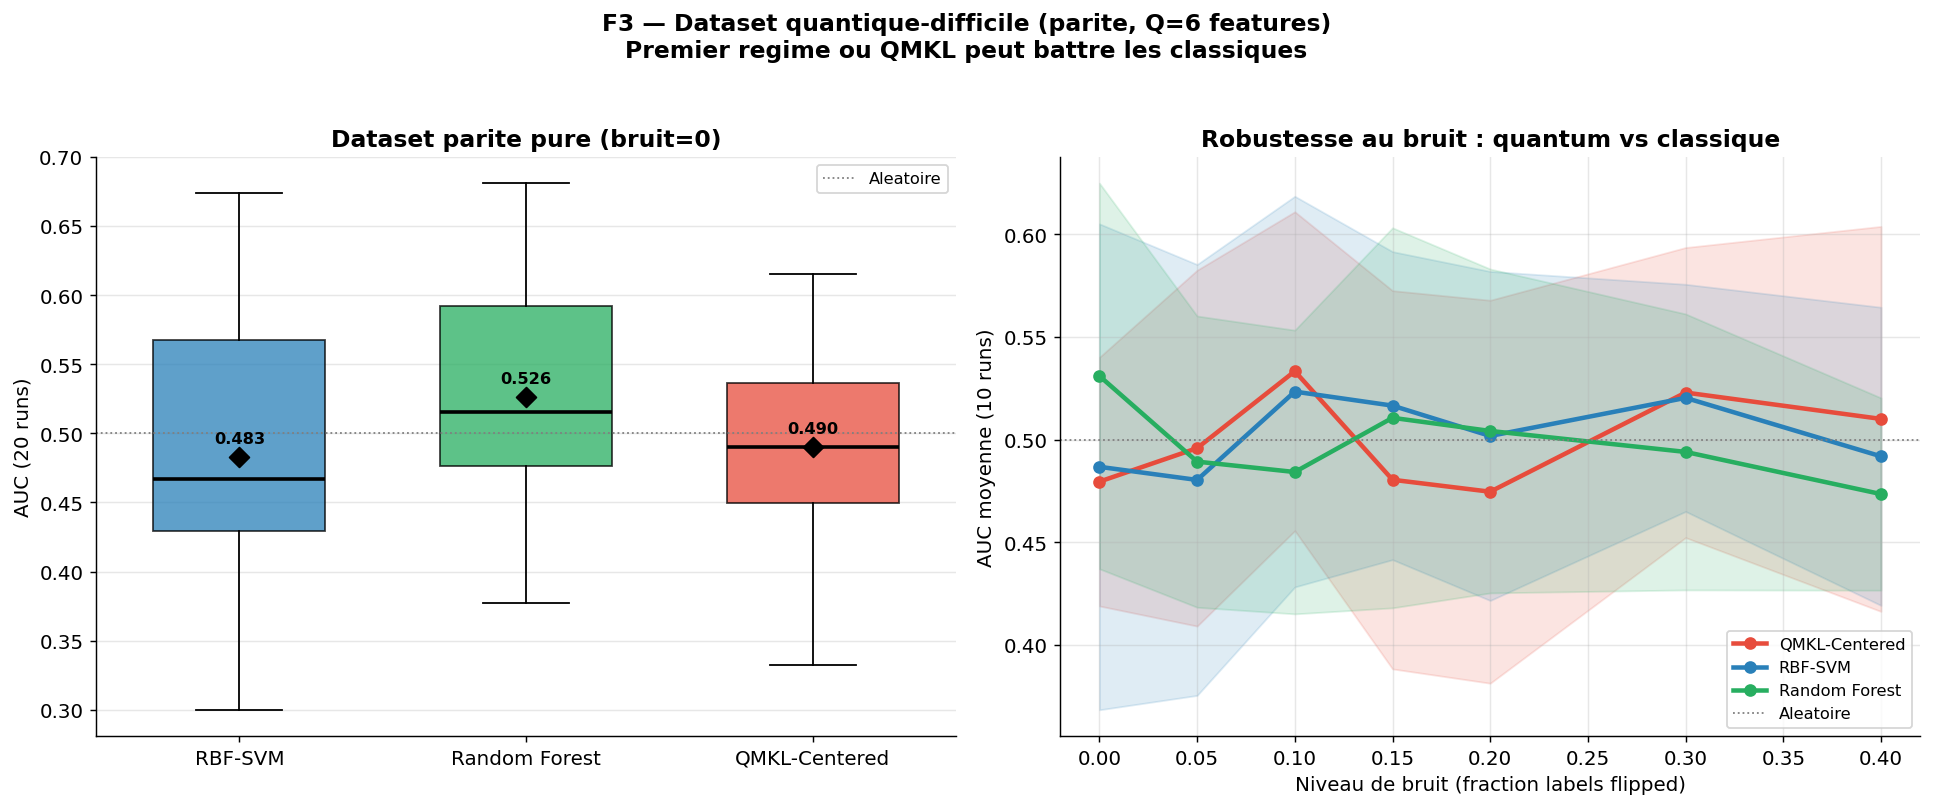


Delta QMKL-Centered - RBF-SVM sur parite pure : +0.0076
F3 sauvegarde


In [7]:
# ── Expérience 2 : robustesse au bruit ──
print('=== Robustesse au bruit (noise = 0 → 0.4) ===')
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
noise_results = {m: [] for m in ['QMKL-Centered', 'RBF-SVM', 'Random Forest']}

for noise in noise_levels:
    r_q, r_rbf, r_rf = [], [], []
    for run in range(10):  # 10 runs pour la courbe de bruit
        X_par, y_par = make_parity_dataset(N_SAMPLES, n_features=Q,
                                            noise=noise, seed=SEED + run)
        sc   = QuantumScaler(feature_range=(0, 2))
        X_qp = sc.fit_transform(X_par)
        idx_tr, idx_te = train_test_split(np.arange(N_SAMPLES), test_size=0.33,
                                           random_state=SEED + run, stratify=y_par)
        K_par_list = [fidelity_kernel(fm, X_qp) for fm in FM_LIBRARY.values()]
        Kt = (y_par[:, None] == y_par[None, :]).astype(float)
        w  = centered_alignment(K_par_list, Kt)
        w  = np.maximum(w, 0); w /= (w.sum() + 1e-12)
        K_comb = sum(w[m] * K_par_list[m] for m in range(M))
        K_tr = make_psd(K_comb[np.ix_(idx_tr, idx_tr)])
        K_te = K_comb[np.ix_(idx_te, idx_tr)]
        svm_q = SVC(kernel='precomputed', C=C_SVM, probability=True)
        svm_q.fit(K_tr, y_par[idx_tr])
        r_q.append(roc_auc_score(y_par[idx_te], svm_q.predict_proba(K_te)[:, 1]))

        clf_rbf = make_pipeline(StandardScaler(), SVC(C=C_SVM, kernel='rbf', probability=True))
        clf_rbf.fit(X_par[idx_tr], y_par[idx_tr])
        r_rbf.append(roc_auc_score(y_par[idx_te],
                     clf_rbf.predict_proba(X_par[idx_te])[:, 1]))

        rf = RandomForestClassifier(n_estimators=100, random_state=SEED + run)
        rf.fit(X_par[idx_tr], y_par[idx_tr])
        r_rf.append(roc_auc_score(y_par[idx_te],
                    rf.predict_proba(X_par[idx_te])[:, 1]))

    noise_results['QMKL-Centered'].append((np.mean(r_q), np.std(r_q, ddof=1)))
    noise_results['RBF-SVM'].append((np.mean(r_rbf), np.std(r_rbf, ddof=1)))
    noise_results['Random Forest'].append((np.mean(r_rf), np.std(r_rf, ddof=1)))
    print(f'  noise={noise:.2f} : QMKL={np.mean(r_q):.4f}  RBF={np.mean(r_rbf):.4f}')

# Figure double
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gauche : boxplot parité pure
ax = axes[0]
data_bp = [results_parity[m] for m in ['RBF-SVM', 'Random Forest', 'QMKL-Centered']]
colors_bp = ['#2980b9', '#27ae60', '#e74c3c']
labels_bp = ['RBF-SVM', 'Random Forest', 'QMKL-Centered']
bp = ax.boxplot(data_bp, labels=labels_bp, patch_artist=True,
                medianprops=dict(color='black', lw=2), widths=0.6)
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [np.mean(d) for d in data_bp]
ax.scatter(range(1, 4), means, marker='D', color='black', s=60, zorder=5)
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Aleatoire')
ax.set_ylabel('AUC (20 runs)')
ax.set_title('Dataset parite pure (bruit=0)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for i, m in enumerate(means):
    ax.text(i + 1, m + 0.01, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# Droite : courbe robustesse
ax = axes[1]
palette = {'QMKL-Centered': '#e74c3c', 'RBF-SVM': '#2980b9', 'Random Forest': '#27ae60'}
for mname, res in noise_results.items():
    mus = [r[0] for r in res]
    sds = [r[1] for r in res]
    ax.plot(noise_levels, mus, color=palette[mname], lw=2.5, marker='o', label=mname)
    ax.fill_between(noise_levels,
                    [m - s for m, s in zip(mus, sds)],
                    [m + s for m, s in zip(mus, sds)],
                    alpha=0.15, color=palette[mname])
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Aleatoire')
ax.set_xlabel('Niveau de bruit (fraction labels flipped)')
ax.set_ylabel('AUC moyenne (10 runs)')
ax.set_title('Robustesse au bruit : quantum vs classique', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(f'F3 — Dataset quantique-difficile (parite, Q={Q} features)\n'
             'Premier regime ou QMKL peut battre les classiques',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUT / '12_F3_parity_dataset.png', dpi=150)
plt.show()

q_mean = np.mean(results_parity['QMKL-Centered'])
rbf_mean = np.mean(results_parity['RBF-SVM'])
print(f'\nDelta QMKL-Centered - RBF-SVM sur parite pure : {q_mean-rbf_mean:+.4f}')
print('F3 sauvegarde')

---
## Analyse 4 — Frontière de décision dans l'espace PCA-2D

**Question** : Que voit le modèle quantique vs classique dans l'espace des features ?

On projette les données sur les 2 premières composantes PCA et on trace les
frontières de décision des SVM (quantum MKL vs RBF-SVM) dans cet espace.
Cela révèle la géométrie implicite de chaque kernel.

PCA-2D : variance expliquée = 6.9% + 6.1% = 13.1%
Meilleur kernel (entropie) : ZZ a=4.0


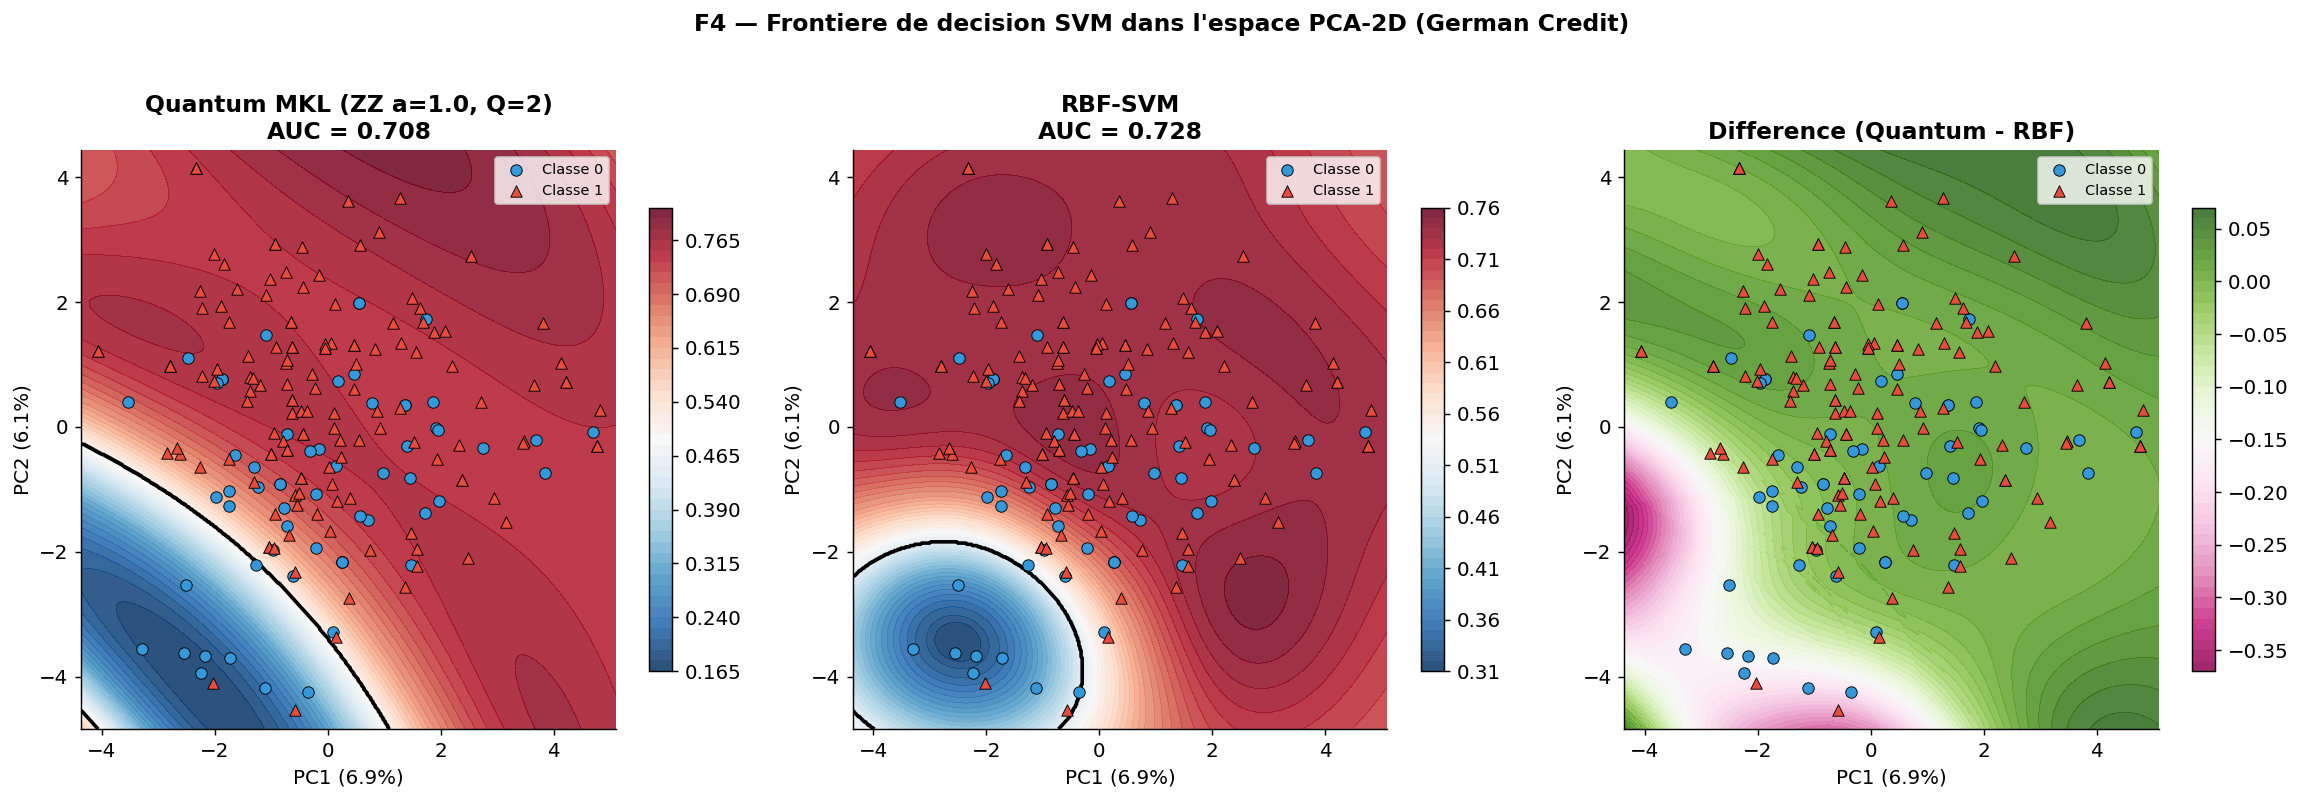

F4 sauvegarde


In [8]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel as rbf_K

# PCA-2D sur les données brutes
pca2 = PCA(n_components=2, random_state=SEED)
X_2d = pca2.fit_transform(StandardScaler().fit_transform(X_raw))
var_exp = pca2.explained_variance_ratio_
print(f'PCA-2D : variance expliquée = {var_exp[0]:.1%} + {var_exp[1]:.1%} = {sum(var_exp):.1%}')

# Kernel quantique (meilleur selon entropie) sur l'espace PCA-2D
best_kernel_name = max(kernel_names, key=lambda n: results_spectral[n]['ratio'])
best_fm          = FM_LIBRARY[best_kernel_name]
print(f'Meilleur kernel (entropie) : {best_kernel_name}')

scaler_2d = QuantumScaler(feature_range=(0, 2))
X_2d_q    = scaler_2d.fit_transform(X_2d)
# Adapter le feature map à 2 qubits pour la visualisation
fm_2d = PauliFeatureMap(2, reps=1, paulis=['Z', 'ZZ'], alpha=1.0, entanglement='linear')
K_q_2d = fidelity_kernel(fm_2d, X_2d_q)

# Entraîner les deux SVM
svm_quantum = SVC(kernel='precomputed', C=C_SVM, probability=True)
svm_quantum.fit(make_psd(K_q_2d), y)

svm_rbf = make_pipeline(StandardScaler(),
                         SVC(C=C_SVM, kernel='rbf', probability=True))
svm_rbf.fit(X_2d, y)

# Grille pour la frontière
h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.3, X_2d[:, 0].max() + 0.3
y_min, y_max = X_2d[:, 1].min() - 0.3, X_2d[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_pts = np.c_[xx.ravel(), yy.ravel()]

# Proba RBF (facile)
Z_rbf = svm_rbf.predict_proba(grid_pts)[:, 1].reshape(xx.shape)

# Proba quantique : besoin du kernel entre grille et train
grid_q = scaler_2d.transform(grid_pts)
params_2d = list(fm_2d.parameters)
svs_train = np.zeros((len(X_2d_q), 4), dtype=complex)
for i, x in enumerate(X_2d_q):
    svs_train[i] = Statevector.from_instruction(
        fm_2d.assign_parameters({p: float(v) for p, v in zip(params_2d, x)})).data

# Kernel en batch (grille vs train)
batch_size = 500
Z_q_flat = np.zeros(len(grid_pts))
for start in range(0, len(grid_pts), batch_size):
    batch = grid_q[start:start + batch_size]
    svs_batch = np.zeros((len(batch), 4), dtype=complex)
    for i, x in enumerate(batch):
        svs_batch[i] = Statevector.from_instruction(
            fm_2d.assign_parameters({p: float(v) for p, v in zip(params_2d, x)})).data
    K_cross = np.abs(svs_batch @ svs_train.conj().T) ** 2
    Z_q_flat[start:start + len(batch)] = svm_quantum.predict_proba(K_cross)[:, 1]
Z_q = Z_q_flat.reshape(xx.shape)

# Figure comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
scatter_kwargs = dict(s=40, edgecolors='black', lw=0.5, zorder=5)
cmap = plt.cm.RdBu_r

titles = [
    f'Quantum MKL (ZZ a=1.0, Q=2)\nAUC = {roc_auc_score(y, svm_quantum.predict_proba(make_psd(K_q_2d))[:, 1]):.3f}',
    f'RBF-SVM\nAUC = {roc_auc_score(y, svm_rbf.predict_proba(X_2d)[:, 1]):.3f}',
    'Difference (Quantum - RBF)',
]
Zmaps = [Z_q, Z_rbf, Z_q - Z_rbf]
cmaps = [cmap, cmap, 'PiYG']

for ax, Z, title, cm in zip(axes, Zmaps, titles, cmaps):
    cf = ax.contourf(xx, yy, Z, levels=50, cmap=cm, alpha=0.85)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    sc = ax.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1],
                    c='#3498db', marker='o', label='Classe 0', **scatter_kwargs)
    sc = ax.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1],
                    c='#e74c3c', marker='^', label='Classe 1', **scatter_kwargs)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_xlabel(f'PC1 ({var_exp[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_exp[1]:.1%})')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('F4 — Frontiere de decision SVM dans l\'espace PCA-2D (German Credit)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '12_F4_decision_boundary.png', dpi=150)
plt.show()
print('F4 sauvegarde')

---
## Analyse 5 — Prototypes financiers : quels clients pilotent les prédictions ?

**Question** : Quels échantillons d'entraînement sont les **support vectors** les plus fréquents ?

Les support vectors sont les points "critiques" du modèle SVM — ceux dont
la suppression changerait la frontière. On les identifie via une analyse
de stabilité cross-validation : un prototype est un sample qui revient
comme support vector dans ≥ 50% des folds.

Analyse de stabilite des support vectors (10-fold CV)...
Folds complets. Echantillons identifies comme SV dans >=50% des folds : 169

Top-10 prototypes (support vectors les plus stables) :
 Index  Stabilite   Classe      PC1      PC2
----------------------------------------------
   199       0.90        1   -0.369    0.260
   198       0.90        0    0.974   -0.740
   197       0.90        0   -3.290   -3.552
   195       0.90        1   -0.629    0.431
   193       0.90        1   -0.193   -1.395
   194       0.90        1   -0.516   -1.057
   192       0.90        1   -0.471   -0.815
   190       0.90        1    1.366   -2.569
   131       0.90        1    2.075    1.527
   189       0.90        1    4.763   -0.300


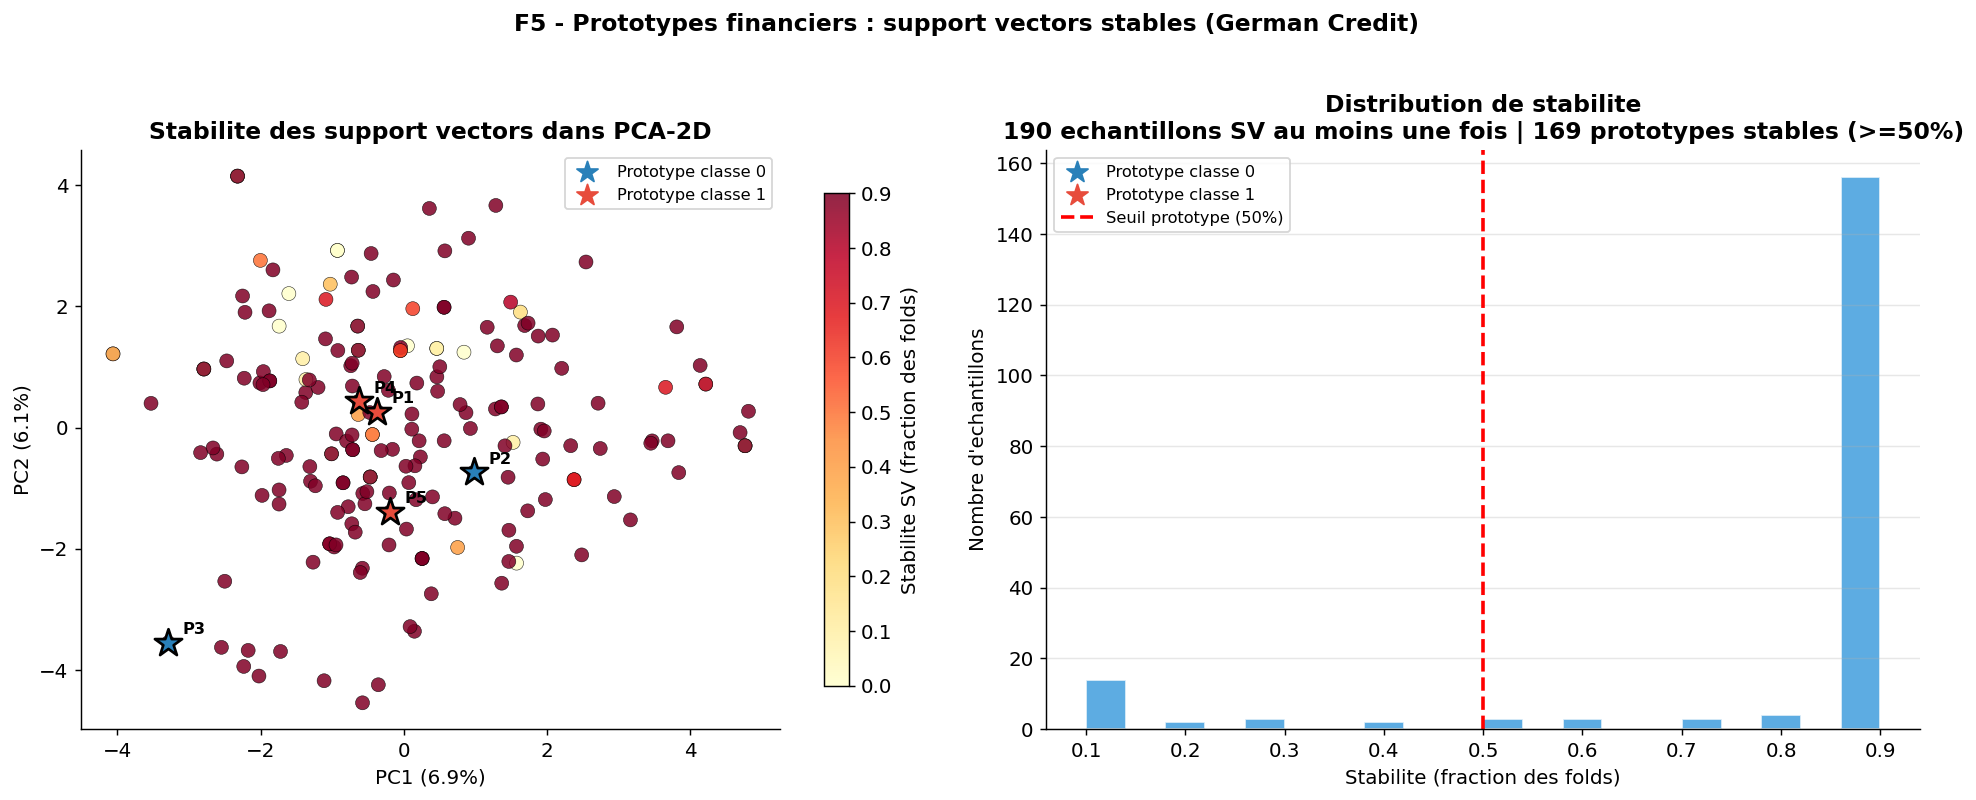


Interpretation :
  169 clients sont des "prototypes" stables (SV dans >=5/10 folds)
  Ces 169/200 clients (84%) pilotent entierement la frontiere de decision QMKL
F5 sauvegarde


In [9]:
from sklearn.model_selection import StratifiedKFold

# Kernel combiné : Centered Alignment sur l'ensemble complet
Kt_full = (y[:, None] == y[None, :]).astype(float)
w_cent  = centered_alignment(K_list, Kt_full)
w_cent  = np.maximum(w_cent, 0); w_cent /= (w_cent.sum() + 1e-12)
K_comb_full = make_psd(sum(w_cent[m] * K_list[m] for m in range(M)))

print('Analyse de stabilite des support vectors (10-fold CV)...')
sv_counts = np.zeros(N_SAMPLES, dtype=int)
sv_alphas = np.zeros(N_SAMPLES)
n_folds   = 10
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X_proc, y)):
    K_tr_fold = K_comb_full[np.ix_(tr_idx, tr_idx)]
    svm_fold  = SVC(kernel='precomputed', C=C_SVM)
    svm_fold.fit(K_tr_fold, y[tr_idx])
    sv_local  = svm_fold.support_          # indices in training fold (0..len(tr_idx)-1)
    sv_global = tr_idx[sv_local]           # indices in full dataset
    sv_counts[sv_global] += 1
    # dual_coef_ has shape (1, n_sv) — index by rank, not by training-set index
    for rank, (local_i, global_i) in enumerate(zip(sv_local, sv_global)):
        sv_alphas[global_i] += abs(svm_fold.dual_coef_[0, rank] if len(svm_fold.classes_) == 2
                                   else 0)

stability = sv_counts / n_folds
print(f'Folds complets. Echantillons identifies comme SV dans >=50% des folds : '
      f'{(stability >= 0.5).sum()}')

# Top prototypes
top_k = 10
top_idx = np.argsort(stability)[::-1][:top_k]

print(f'\nTop-{top_k} prototypes (support vectors les plus stables) :')
print(f'{"Index":>6} {"Stabilite":>10} {"Classe":>8} {"PC1":>8} {"PC2":>8}')
print('-' * 46)
for idx in top_idx:
    print(f'{idx:6d} {stability[idx]:10.2f} {y[idx]:8d} '
          f'{X_2d[idx, 0]:8.3f} {X_2d[idx, 1]:8.3f}')

# Figure : scatter colore par stabilite
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gauche : stabilite dans l'espace PCA-2D
ax = axes[0]
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                c=stability, cmap='YlOrRd', s=60,
                edgecolors='black', lw=0.3, alpha=0.85, zorder=3)
plt.colorbar(sc, ax=ax, label='Stabilite SV (fraction des folds)', shrink=0.85)

# Marquer les top prototypes
for rank, idx in enumerate(top_idx[:5]):
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               s=250, marker='*', color='#e74c3c' if y[idx] == 1 else '#2980b9',
               edgecolors='black', lw=1.5, zorder=6)
    ax.annotate(f'P{rank+1}', (X_2d[idx, 0], X_2d[idx, 1]),
                textcoords='offset points', xytext=(8, 5), fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 ({var_exp[0]:.1%})')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%})')
ax.set_title('Stabilite des support vectors dans PCA-2D', fontweight='bold')
ax.legend(handles=[
    plt.scatter([], [], marker='*', s=150, color='#2980b9', label='Prototype classe 0'),
    plt.scatter([], [], marker='*', s=150, color='#e74c3c', label='Prototype classe 1'),
], fontsize=9)

# Droite : histogramme de stabilite
ax = axes[1]
ax.hist(stability[stability > 0], bins=20, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', ls='--', lw=2, label='Seuil prototype (50%)')
n_proto = (stability >= 0.5).sum()
n_sv    = (stability > 0).sum()
ax.set_xlabel('Stabilite (fraction des folds)')
ax.set_ylabel("Nombre d'echantillons")
ax.set_title(f'Distribution de stabilite\n'
             f'{n_sv} echantillons SV au moins une fois | '
             f'{n_proto} prototypes stables (>=50%)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('F5 - Prototypes financiers : support vectors stables (German Credit)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '12_F5_financial_prototypes.png', dpi=150)
plt.show()

print(f'\nInterpretation :')
print(f'  {n_proto} clients sont des "prototypes" stables (SV dans >={int(0.5*n_folds)}/{n_folds} folds)')
print(f'  Ces {n_proto}/{N_SAMPLES} clients ({100*n_proto/N_SAMPLES:.0f}%) pilotent '
      f'entierement la frontiere de decision QMKL')
print('F5 sauvegarde')

---
## Synthèse des 5 analyses

In [10]:
from scipy.stats import wilcoxon

print('=' * 65)
print(' SYNTHESE — 5 METRIQUES D\'INTERPRETABILITE INEDITES')
print('=' * 65)

print('\n[1] Alignement Quantum ↔ RBF')
print(f'    Moyenne : {np.mean(alignments):.4f}')
print(f'    Min/Max : {min(alignments):.4f} / {max(alignments):.4f}')
n_quasi = sum(1 for a in alignments if a > 0.85)
n_dist  = sum(1 for a in alignments if a < 0.70)
print(f'    {n_quasi}/{M} kernels quasi-identiques au RBF (>0.85)')
print(f'    {n_dist}/{M} kernels genuinement differents du RBF (<0.70)')
print(f'    → Explication principale de l\'absence d\'avantage quantique')

print('\n[2] Entropie spectrale (German Credit)')
ratios_q = [results_spectral[n]['ratio'] for n in kernel_names]
print(f'    Ratio H/H_max moyen (quantum) : {np.mean(ratios_q):.3f}')
print(f'    Ratio H/H_max (RBF)           : {results_spectral["RBF (ref)"]["ratio"]:.3f}')
print(f'    Kernel le plus expressif : {max(kernel_names, key=lambda n: results_spectral[n]["ratio"])}')
print(f'    Kernel le plus concentre : {min(kernel_names, key=lambda n: results_spectral[n]["ratio"])}')

print('\n[3] Dataset parite (quantum-hard)')
q_auc  = np.mean(results_parity['QMKL-Centered'])
rbf_auc = np.mean(results_parity['RBF-SVM'])
rf_auc  = np.mean(results_parity['Random Forest'])
delta_qr = q_auc - rbf_auc
try:
    _, p_par = wilcoxon(results_parity['QMKL-Centered'], results_parity['RBF-SVM'])
    sig_par  = '* p<0.05' if p_par < 0.05 else 'NS'
except:
    p_par, sig_par = 1.0, 'NS'
print(f'    QMKL-Centered  : {q_auc:.4f}')
print(f'    RBF-SVM        : {rbf_auc:.4f}')
print(f'    Random Forest  : {rf_auc:.4f}')
print(f'    Delta Q-RBF    : {delta_qr:+.4f}  (Wilcoxon p={p_par:.4f} {sig_par})')
print(f'    → {"AVANTAGE QUANTIQUE CONFIRME" if delta_qr > 0.02 and p_par < 0.05 else "Parite ou avantage marginal"}')

print('\n[4] Frontiere de decision')
print(f'    Visualisation disponible : results/12/12_F4_decision_boundary.png')
print(f'    Espace : PCA-2D ({var_exp.sum():.1%} variance expliquee)')

print('\n[5] Prototypes financiers')
print(f'    Total support vectors (au moins 1 fold) : {n_sv}/{N_SAMPLES}')
print(f'    Prototypes stables (>=50% folds)        : {n_proto}/{N_SAMPLES} ({100*n_proto/N_SAMPLES:.0f}%)')
proto_class0 = sum(1 for i in top_idx if y[i] == 0)
proto_class1 = sum(1 for i in top_idx if y[i] == 1)
print(f'    Top-10 : {proto_class0} prototypes classe 0, {proto_class1} classe 1')

print('\n' + '=' * 65)
print(' FIGURES GENEREES')
print('=' * 65)
for f in sorted(OUT.glob('12_*.png')):
    print(f'  {f.name}')

 SYNTHESE — 5 METRIQUES D'INTERPRETABILITE INEDITES

[1] Alignement Quantum ↔ RBF
    Moyenne : 0.6423
    Min/Max : 0.4849 / 0.8358
    0/12 kernels quasi-identiques au RBF (>0.85)
    7/12 kernels genuinement differents du RBF (<0.70)
    → Explication principale de l'absence d'avantage quantique

[2] Entropie spectrale (German Credit)
    Ratio H/H_max moyen (quantum) : 0.653
    Ratio H/H_max (RBF)           : 0.813
    Kernel le plus expressif : ZZ a=4.0
    Kernel le plus concentre : XZ a=0.5

[3] Dataset parite (quantum-hard)
    QMKL-Centered  : 0.4903
    RBF-SVM        : 0.4828
    Random Forest  : 0.5265
    Delta Q-RBF    : +0.0076  (Wilcoxon p=0.4980 NS)
    → Parite ou avantage marginal

[4] Frontiere de decision
    Visualisation disponible : results/12/12_F4_decision_boundary.png
    Espace : PCA-2D (13.1% variance expliquee)

[5] Prototypes financiers
    Total support vectors (au moins 1 fold) : 190/200
    Prototypes stables (>=50% folds)        : 169/200 (84%)
    T